In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

In [3]:
base_path = "../dataframe/BD_Atlas_1991_2024_Monte_Carlo.csv"
base_data = pd.read_csv(base_path)

In [1]:
class FeatureSimulation:
    def __init__(self, data, feature_name, distribs_candidates):
        """
        data: pd.Series com os dados históricos da feature
        feature_name: nome da feature (string)
        distribs_candidates: lista de strings com distribuições do scipy.stats para testar
        """
        self.data = data.dropna()
        self.feature_name = feature_name
        self.distribs_candidates = distribs_candidates
        self.best_fit = None
        self.best_params = None
        self.best_dist_name = None
        self.fit_results = {}

    def fit_distributions(self):
        """Ajusta todas distribuições candidatas e escolhe a melhor via SSE (soma dos erros quadráticos)."""
        hist, bin_edges = np.histogram(self.data, bins=30, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        best_sse = np.inf
        for dist_name in self.distribs_candidates:
            dist = getattr(stats, dist_name)
            try:
                params = dist.fit(self.data)
                pdf_fitted = dist.pdf(bin_centers, *params[:-2], loc=params[-2], scale=params[-1])
                sse = np.sum((hist - pdf_fitted) ** 2)
                self.fit_results[dist_name] = (sse, params)
                if sse < best_sse:
                    best_sse = sse
                    self.best_fit = dist
                    self.best_params = params
                    self.best_dist_name = dist_name
            except Exception as e:
                print(f"Erro ao ajustar {dist_name} para {self.feature_name}: {e}")
                continue

    def plot_fit(self):
        """Plota histograma dos dados e PDF da distribuição ajustada."""
        plt.figure(figsize=(8,5))
        sns.histplot(self.data, bins=30, stat='density', color='skyblue', label='Dados históricos')
        x = np.linspace(self.data.min(), self.data.max(), 100)
        pdf_fitted = self.best_fit.pdf(x, *self.best_params[:-2], loc=self.best_params[-2], scale=self.best_params[-1])
        plt.plot(x, pdf_fitted, 'r-', label=f'Ajuste: {self.best_dist_name}')
        plt.title(f'Ajuste de distribuição para {self.feature_name}')
        plt.legend()
        plt.show()

    def simulate(self, n_sim=10000, scenario='normal', param_adjust={'loc':0, 'scale':1}):
        """
        Simula dados usando a distribuição ajustada.
        param_adjust: dict para multiplicar/ajustar loc e scale para melhores/piores cenários
        """
        loc = self.best_params[-2] * param_adjust.get('loc',1)
        scale = self.best_params[-1] * param_adjust.get('scale',1)
        args = self.best_params[:-2]
        samples = self.best_fit.rvs(*args, loc=loc, scale=scale, size=n_sim)
        return samples

    def confidence_intervals(self, samples, confidence=0.95):
        """Calcula intervalo de confiança nos dados simulados."""
        lower = np.percentile(samples, (1-confidence)/2*100)
        upper = np.percentile(samples, (1+(confidence))/2*100)
        return lower, upper

    def prob_extreme_event(self, samples, threshold, above=True):
        """Calcula probabilidade do evento extremo, acima ou abaixo do threshold."""
        if above:
            return np.mean(samples > threshold)
        else:
            return np.mean(samples < threshold)

    def run_full_simulation(self, n_sim=10000):
        """
        Roda simulações para três cenários: melhor, normal e pior caso.
        Ajustes simples:
          * Melhor caso: loc*0.8, scale*0.8
          * Normal: loc*1, scale*1
          * Pior caso: loc*1.2, scale*1.5
        """
        scenarios = {
            'Melhor caso': {'loc': 0.8, 'scale': 0.8},
            'Normal': {'loc': 1, 'scale': 1},
            'Pior caso': {'loc': 1.2, 'scale': 1.5}
        }
        results = {}
        for sc_name, adj in scenarios.items():
            sim_data = self.simulate(n_sim=n_sim, scenario=sc_name, param_adjust=adj)
            ci = self.confidence_intervals(sim_data)
            results[sc_name] = {
                'simulated_data': sim_data,
                'confidence_interval_95': ci,
                'mean': np.mean(sim_data),
                'std': np.std(sim_data),
            }
            print(f"Cenário: {sc_name} | Média: {results[sc_name]['mean']:.2f} | 95% CI: {ci}")

            # Exemplo de probabilidade de evento extremo (acima do 95% dos dados históricos)
            thresh = np.percentile(self.data, 95)
            prob_extreme = self.prob_extreme_event(sim_data, thresh, above=True)
            print(f"Probabilidade de evento > {thresh:.2f}: {prob_extreme:.3f}")

        return results


Analisando feature: DH_MORTOS


C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:6921: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:1545: RuntimeWarning: overflow encountered in divide
  x = (asarray(x)-loc) / scale
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


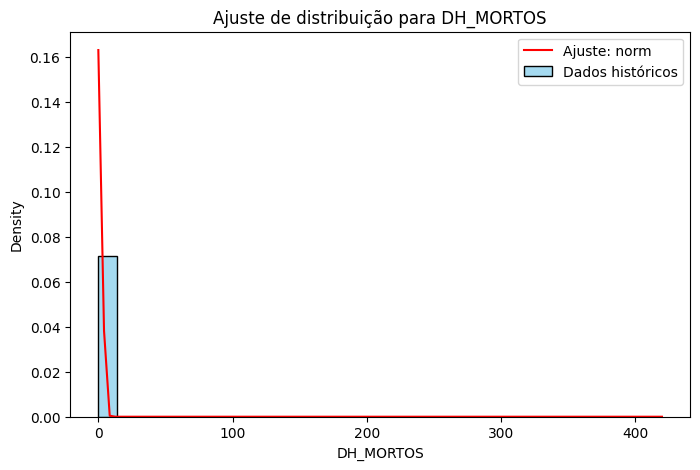

Cenário: Melhor caso | Média: 0.10 | 95% CI: (np.float64(-3.6919159758428117), np.float64(3.845715580836172))
Probabilidade de evento > 0.00: 0.523
Cenário: Normal | Média: 0.09 | 95% CI: (np.float64(-4.623222754084303), np.float64(4.795990093608026))
Probabilidade de evento > 0.00: 0.514
Cenário: Pior caso | Média: 0.08 | 95% CI: (np.float64(-7.089152469649691), np.float64(7.232320679287767))
Probabilidade de evento > 0.00: 0.513

Analisando feature: DH_FERIDOS


C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:6921: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:1545: RuntimeWarning: overflow encountered in divide
  x = (asarray(x)-loc) / scale
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


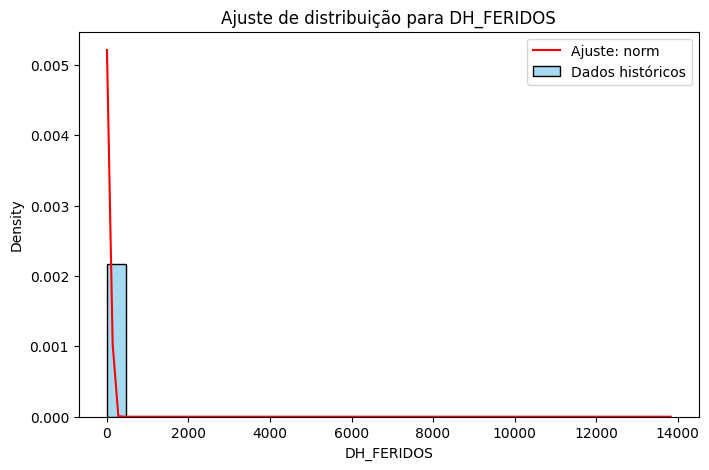

Cenário: Melhor caso | Média: 2.68 | 95% CI: (np.float64(-117.80604645692158), np.float64(122.73715983503676))
Probabilidade de evento > 1.00: 0.511
Cenário: Normal | Média: 3.06 | 95% CI: (np.float64(-141.88465158786553), np.float64(152.4597481491315))
Probabilidade de evento > 1.00: 0.513
Cenário: Pior caso | Média: 3.00 | 95% CI: (np.float64(-222.8036465529623), np.float64(226.59281685205178))
Probabilidade de evento > 1.00: 0.506

Analisando feature: DM_Uni Habita Destruidas


C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:6921: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


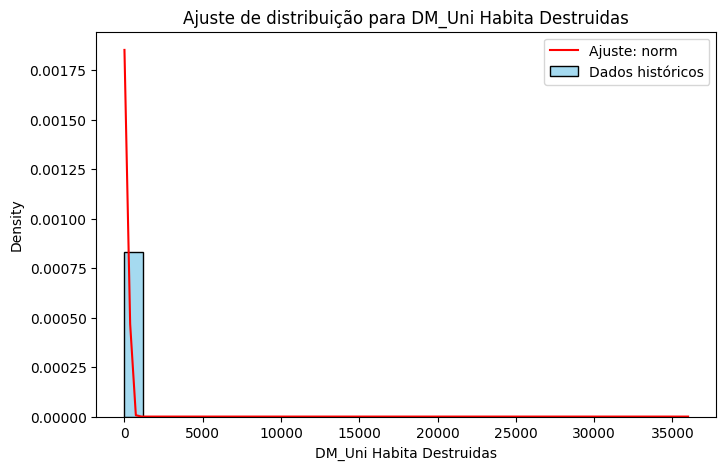

Cenário: Melhor caso | Média: 9.99 | 95% CI: (np.float64(-329.26072848937946), np.float64(349.8877781097125))
Probabilidade de evento > 6.00: 0.514
Cenário: Normal | Média: 3.70 | 95% CI: (np.float64(-412.9137254177226), np.float64(421.79761526295607))
Probabilidade de evento > 6.00: 0.495
Cenário: Pior caso | Média: 0.87 | 95% CI: (np.float64(-627.2227530708302), np.float64(628.757484549548))
Probabilidade de evento > 6.00: 0.491

Analisando feature: PEPL_Ensino (R$)


C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:6921: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
C:\Users\Marcos Vinicios\Documents\GitHub\Computa-o-de-baixo-desempenho\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


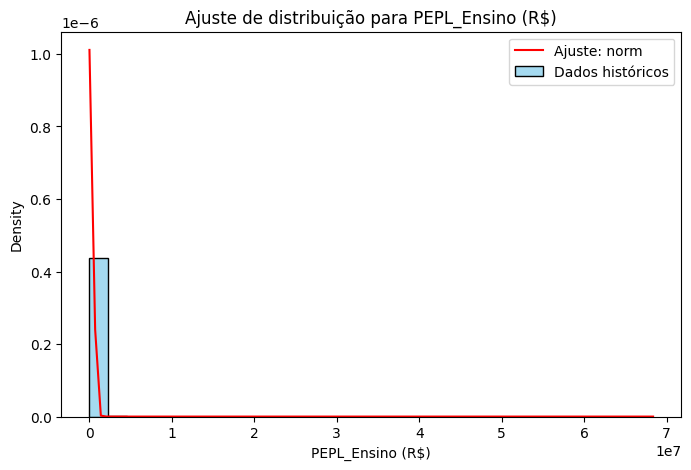

Cenário: Melhor caso | Média: 15294.32 | 95% CI: (np.float64(-594579.8513776155), np.float64(625638.5821936366))
Probabilidade de evento > 20000.00: 0.492
Cenário: Normal | Média: 16668.88 | 95% CI: (np.float64(-749594.8680221405), np.float64(796016.0911342454))
Probabilidade de evento > 20000.00: 0.494
Cenário: Pior caso | Média: 34828.24 | 95% CI: (np.float64(-1114527.1832145785), np.float64(1193735.584870372))
Probabilidade de evento > 20000.00: 0.511


ValueError: cannot reshape array of size 10000 into shape (34)

<Figure size 1200x600 with 0 Axes>

In [8]:

# Escolher features numéricas para análise
features_to_analyze = [
    'DH_MORTOS',
    'DH_FERIDOS',
    'DM_Uni Habita Destruidas',
    'PEPL_Ensino (R$)'
]

# Distribuições candidatas para ajustar (pode personalizar)
distribuicoes = ['norm', 'lognorm', 'gamma', 'weibull_min']

sim_results = {}

for feat in features_to_analyze:
    print(f'\nAnalisando feature: {feat}')
    fsim = FeatureSimulation(base_data[feat], feat, distribuicoes)
    fsim.fit_distributions()
    fsim.plot_fit()
    results = fsim.run_full_simulation(n_sim=10000)
    sim_results[feat] = results

# Você pode expandir para plotar séries temporais simuladas, agregando por ano (exemplo abaixo):
def plot_time_series_simulations(df, feature, sim_data_dict, years_col='Data_Evento', n_sim=1000):
    import matplotlib.dates as mdates

    # Assumindo Data_Evento formato datetime
    df['year'] = pd.to_datetime(df[years_col]).dt.year
    years = sorted(df['year'].unique())

    plt.figure(figsize=(12,6))
    for scenario, info in sim_data_dict.items():
        # Simula agregados anuais: média de n_sim simulações divididas igualmente pelos anos (simplificação)
        sim_annual_avg = np.mean(info['simulated_data'].reshape(-1, len(years)), axis=0)
        plt.plot(years, sim_annual_avg, label=scenario)

    plt.title(f'Séries temporais simuladas para {feature}')
    plt.xlabel('Ano')
    plt.ylabel(feature)
    plt.legend()
    plt.show()

# Exemplo para a primeira feature
plot_time_series_simulations(base_data, features_to_analyze[0], sim_results[features_to_analyze[0]])

In [32]:
trash = ['DH_Descricao', 'DM_Descricao', 'DA_Descricao', 'PEPL_Descricao', 'PEPR_Descricao']
base_data = base_data.drop(columns=trash)

In [35]:
base_data.dtypes

Protocolo_S2iD         object
Nome_Municipio         object
Sigla_UF               object
regiao                 object
Data_Registro          object
                        ...  
PEPR_Indústria (R$)    object
PEPR_Comércio (R$)     object
PEPR_Serviços (R$)     object
PEPR_total_privado     object
PE_PLePR               object
Length: 64, dtype: object

# colunas com dados ausentes;

In [28]:
# colunas com dados ausentes;
base_data['Setores Censitários'].value_counts()

Setores Censitários
241340905000003                                                                                                                                                                                                                                                                                                                                                                                                                            13
150530405000028                                                                                                                                                                                                                                                                                                                                                                                                                            12
241340905000009                                                                                                         

In [21]:
base_data['set'].value_counts()

DH_Descricao
População afetada direta e indiretamente pelo desabastecimento de água potável, perdas na agricultura e pecuária.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         264
Relacionam-se as pessoas residentes na zona rural afetada pela estiagem.                                                                                                                                                                                                                     

In [22]:
base_data['DM_Descricao'].value_counts()

DM_Descricao
NÃO HOUVE\r\n                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      1126
Não houve danos materiais.                                                                                                                                                                                                                                                                         

In [23]:
base_data['DA_Descricao'].value_counts()

DA_Descricao
NÃO HOUVE                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           217
Não houve.                         

In [24]:
base_data['DA_Polui/cont da água'].value_counts()

DA_Polui/cont da água
MAIS DE 20% DA POPULAÇÃO AFETADA     254
DE 0% A 5% DA POPULAÇÃO AFETADA      241
MAIS DE 20%                          198
DE 0% A 5%                           173
DE 5% A 10% DA POPULAÇÃO AFETADA     101
DE 10% A 20% DA POPULAÇÃO AFETADA     95
DE 5% A 10%                           89
DE 10% A 20%                          75
Name: count, dtype: int64

In [30]:
base_data['Status'].value_counts()

Status
Registro                      33514
Reconhecido                   31080
Não reconhecido                2387
Não homologado pelo estado      141
Homologado pelo estado          108
Name: count, dtype: int64